### imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, stats
from skimage import measure
import pandas as pd

### array to df

In [11]:
# load npy file for participant
participant = 5
trial_number = 36
file_path = f'/Users/anji/Desktop/lab project/EyeData/controls/ctrl_{participant}.npy'
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

### pupil dilation

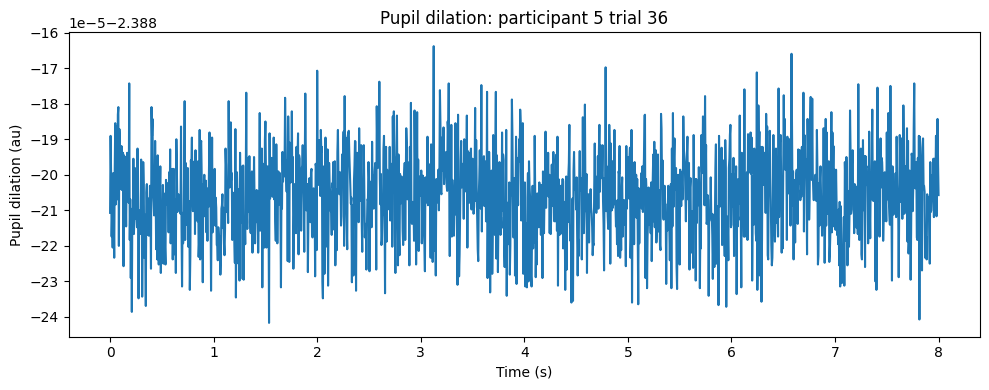

In [12]:
fs = 200  # sampling frequency Hz
samples = 1601

time = np.arange(samples) / fs

plt.figure(figsize=(10,4))
plt.plot(time, df['pupil'])
plt.title(f'Pupil dilation: participant {participant} trial {trial_number}')
plt.xlabel('Time (s)')
plt.ylabel('Pupil dilation (au)')
plt.tight_layout()
plt.show()

### blink check

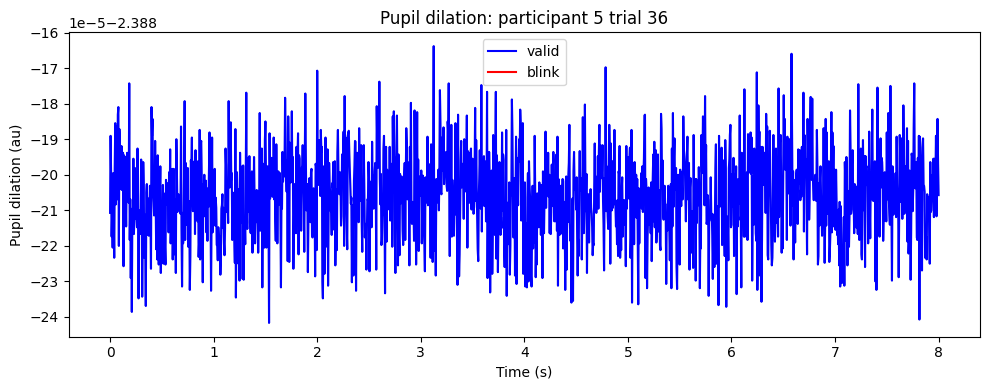

In [13]:
blink_mask = df['pupil'] < -4.0 # True = blink, False = valid
blink_mask = ndimage.binary_dilation(blink_mask, iterations=15)
time = np.arange(samples) / fs

# trial_pupil = ndimage.binary_dilation(trial_pupil)

plt.figure(figsize=(10,4))

# entire signal in light grey
plt.plot(time, df['pupil'], color='lightgrey')

# valid segments
plt.plot(time[~blink_mask], df['pupil'][~blink_mask],
         color='blue', label='valid')

# blink segments
plt.plot(time[blink_mask], df['pupil'][blink_mask],
         color='red', label='blink')

plt.title(f'Pupil dilation: participant {participant} trial {trial_number}')
plt.xlabel('Time (s)')
plt.ylabel('Pupil dilation (au)')
plt.legend()
plt.tight_layout()
plt.show()

### visualising the trial

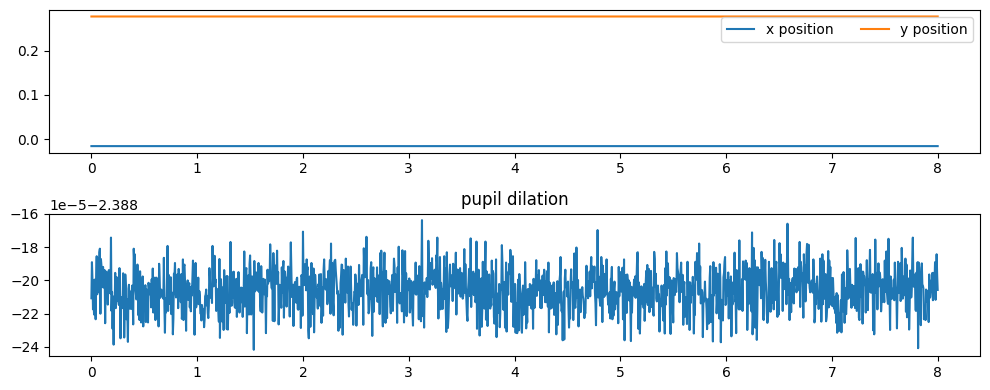

In [14]:
plt.figure(figsize = (10,4))
plt.subplot(2,1,1)
plt.plot(time, df['x'], label = 'x position')
plt.subplot(2,1,1)
plt.plot(time, df['y'], label = 'y position')
plt.legend(loc = 'upper right', ncol = 2)

plt.subplot(2,1,2)
plt.title('pupil dilation')
plt.plot(time, df['pupil'])
plt.tight_layout()

plt.show()

### ignoring blinks

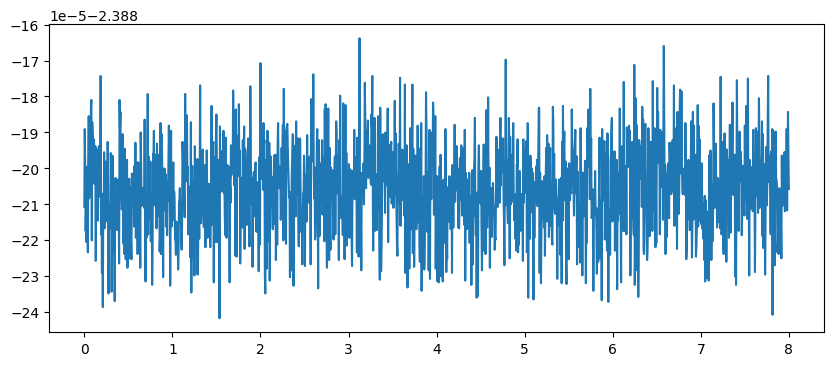

In [15]:
df_clean = df.copy()
df_clean.loc[blink_mask, :] = np.nan

plt.figure(figsize=(10,4))
plt.plot(time,df_clean['pupil'])
plt.show()

### saccade info:

number of saccades = 104


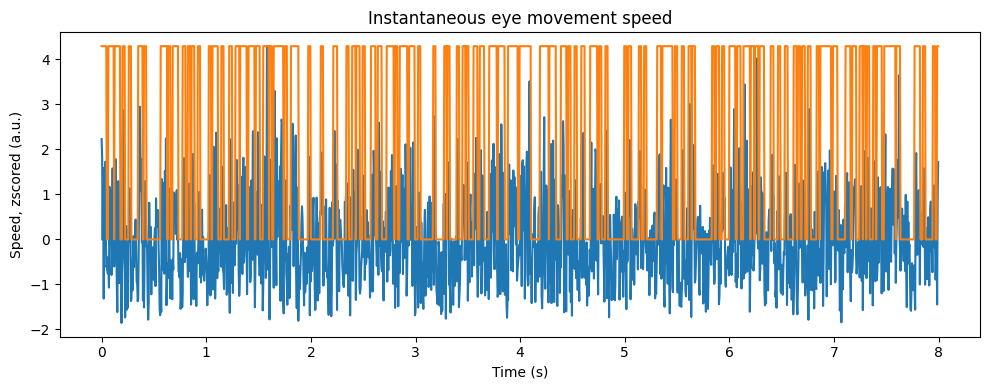

number of saccades = 104
     label  start_s  end_s  duration_ms  mean_speed  max_speed
0        1    0.000  0.045         50.0    0.773018   2.230352
1        2    0.065  0.115         55.0    0.162835   1.579532
2        3    0.125  0.175         55.0    0.084023   1.782987
3        4    0.200  0.220         25.0    0.562940   2.870039
4        5    0.260  0.280         25.0    0.165007   1.134585
..     ...      ...    ...          ...         ...        ...
99     100    7.595  7.630         40.0    0.865943   3.646680
100    101    7.770  7.820         55.0    0.064207   1.919508
101    102    7.850  7.870         25.0    0.220740   1.579658
102    103    7.945  7.965         25.0    0.255489   1.202049
103    104    7.985  7.995         15.0    0.372115   1.722662

[104 rows x 6 columns]


In [16]:
samples = data.shape[1]
trials = data.shape[2]

merging_ms = 10
thr_z = 1

x = df_clean['x']
y = df_clean['y']
pupil = df_clean['pupil']

xdiff = np.diff(x) ** 2
ydiff = np.diff(y) ** 2
speed = np.sqrt(xdiff + ydiff)
speed_z = stats.zscore(speed, nan_policy = 'omit')
time = np.arange(len(speed)) / fs  # seconds (fs = 200Hz)

plt.figure(figsize=(10,4))

plt.plot(time, speed_z)


plt.title('Instantaneous eye movement speed')
plt.xlabel('Time (s)')
plt.ylabel('Speed, zscored (a.u.)')
plt.tight_layout()

# --- saccade statistics ---
iters = max(1, int((merging_ms / 1000.0) * fs))   # samples to merge at fs Hz

raw = speed_z > thr_z
# print('raw > thr_z:', int(raw.sum()))
# print('iters (samples merged):', iters)
# merge short gaps between supra-threshold samples
saccades = ndimage.binary_dilation(raw, iterations=iters)
# optional gentle cleanup to remove isolated single-sample noise (commented by default)
# saccades = ndimage.binary_opening(saccades)

labelled, n = ndimage.label(saccades.astype(np.uint8))
regions = ndimage.find_objects(labelled)

# for i in regions: 
#     start = (time[i[0].start]).round(4)
#     end = (time[i[0].stop - 1]).round(4)
#     duration_ms = ((end - start)* 1000).round(4)
#     print(f'{start}s -> {end}s  (duration {duration_ms}ms)')

movement = saccades
print(f'number of saccades = {n}')

plt.plot(time, movement*np.nanmax(speed_z))

plt.show()

labels = measure.label(movement.astype(np.uint8), connectivity=1)
props = measure.regionprops_table(
    labels[:, None],                 # make it 2-D for skimage
    intensity_image=speed_z[:, None],  # to get mean/max speed per saccade
    properties=('label', 'area', 'bbox', 'mean_intensity', 'max_intensity')
)

stats_df = pd.DataFrame(props).rename(
    columns = {
        'area': 'n_samples',
        'bbox-0': 'start_idx',
        'bbox-2': 'end_idx_exclusive',
        'mean_intensity': 'mean_speed',
        'max_intensity': 'max_speed'
    }
)

stats_df['end_idx'] = stats_df['end_idx_exclusive'] - 1
stats_df['start_s'] = stats_df['start_idx'] / fs
stats_df['end_s'] = stats_df['end_idx'] / fs
stats_df['duration_ms'] = (stats_df['n_samples'] / fs) * 1000


print(f"number of saccades = {len(stats_df)}")
print(stats_df[['label','start_s','end_s','duration_ms','mean_speed','max_speed']])

### exclude noisy trials

some trials (eg. participant 10 trial 23) are super noisy - can just be thrown out entirely on basis of variance?

In [17]:
# load npy file for participant
participant = 5
trial_number = 36
file_path = f'/Users/anji/Desktop/lab project/EyeData/controls/ctrl_{participant}.npy'
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

pupvar = np.var(df['pupil'])
xvar = np.var(df['x'])
yvar = np.var(df['y'])
print(f'''variance: \n pupil = {pupvar},
      x = {xvar},
      y = {yvar}''')

variance: 
 pupil = 1.532888113418944e-10,
      x = 8.292741141595373e-11,
      y = 6.194608408863724e-11
